In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = "../data/raw/Registro A_2.MOV"
cap = cv2.VideoCapture(VIDEO_PATH)

print("Video abierto:", cap.isOpened())
print("Cantidad de frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("FPS:", cap.get(cv2.CAP_PROP_FPS))
print("Ancho:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Alto:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

ROI_PATH = "../data/reference/roi_A_gray.png"

roi_gray = cv2.imread(ROI_PATH, cv2.IMREAD_GRAYSCALE)

if roi_gray is None:
    raise RuntimeError(f"No se pudo cargar la ROI: {ROI_PATH}")

print("ROI cargada correctamente.")
print("Dimensiones:", roi_gray.shape)

Video abierto: True
Cantidad de frames: 956
FPS: 29.97804954531201
Ancho: 1920
Alto: 1080
ROI cargada correctamente.
Dimensiones: (130, 320)


Se carga el video y la ROI seleccionada en el módulo 1 para aplicarle los métodos de segmentación y observar su funcionamiento. 

Se aplica el método de Otsu para determinar automáticamente un umbral que permita separar la región oscura correspondiente a la pupila del resto de la imagen. Luego se realiza una operación morfológica para eliminar pequeños objetos y suavizar la región segmentada.

Umbral de Otsu: 107.0


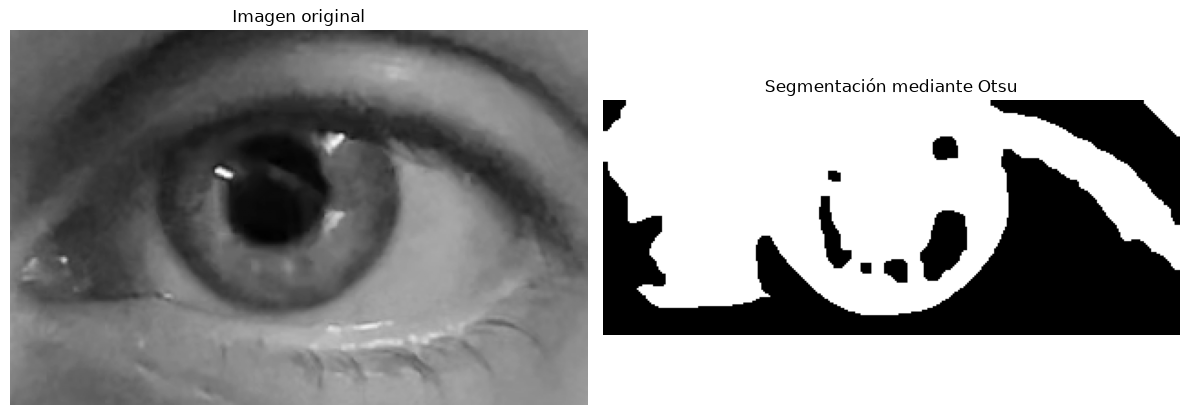

In [63]:
blur = cv2.GaussianBlur(roi_gray, (5, 5), sigmaX=2)

threshold, mask_otsu = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((5, 5), np.uint8)

mask_otsu = cv2.morphologyEx(
    mask_otsu,
    cv2.MORPH_CLOSE,
    kernel
)

print("Umbral de Otsu:", threshold)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_otsu, cmap="gray")
plt.title("Segmentación mediante Otsu")
plt.axis("off")

plt.tight_layout()
plt.show()

Se utiliza el algoritmo K-Means para agrupar los píxeles de la imagen en distintos grupos según sus características de color e intensidad. Se evalúan valores de K entre 2 y 5 para analizar cómo cambia la segmentación de la pupila al aumentar la cantidad de grupos.

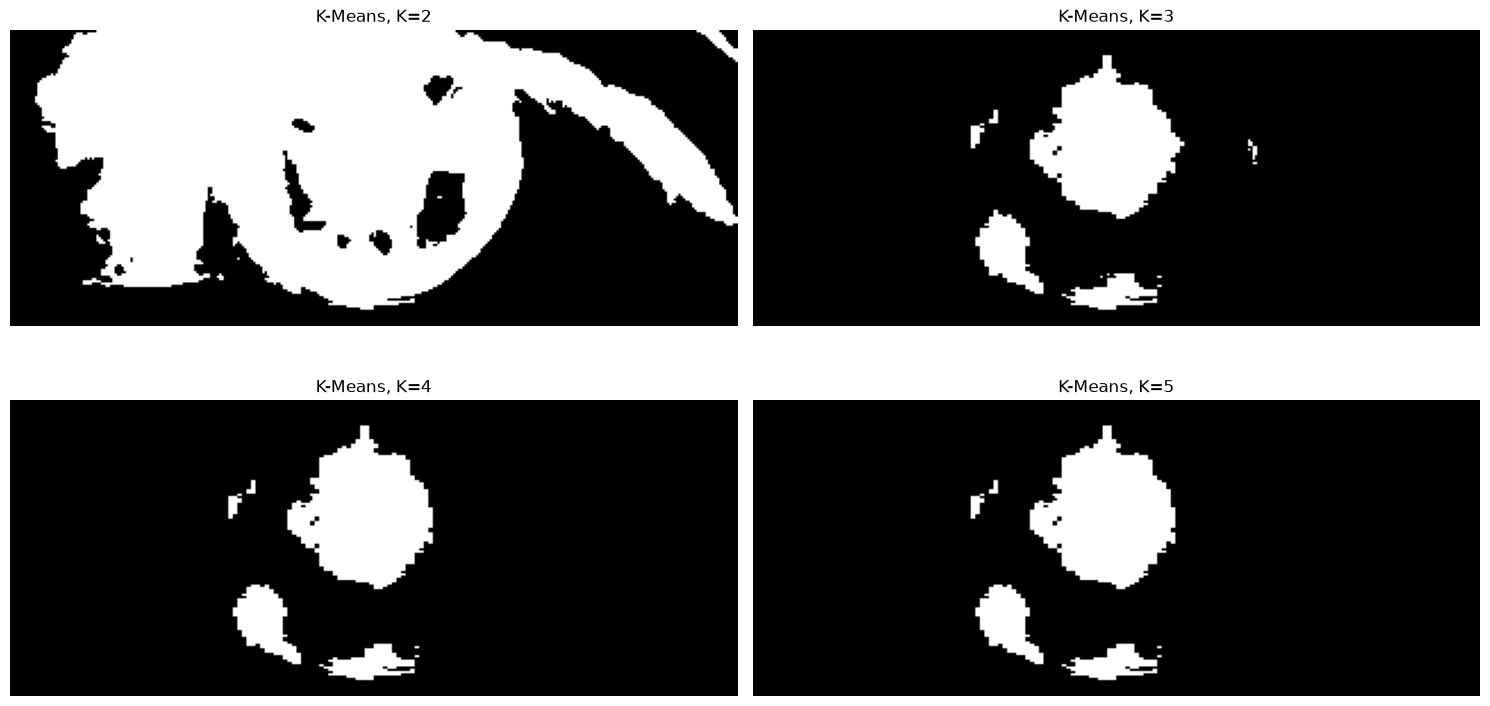

In [55]:
ROI_RGB_PATH = "../data/reference/roi_A_rgb.png"

roi_rgb = cv2.imread(ROI_RGB_PATH)

hsv = cv2.cvtColor(roi_rgb, cv2.COLOR_BGR2HSV)
pixels = hsv.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
results_kmeans = {}

for k in range(2, 6):
    _, labels, centers = cv2.kmeans(pixels,k,None,criteria,10,cv2.KMEANS_PP_CENTERS)

    labels = labels.flatten()
    centers = centers.astype(np.uint8)

    cluster_image = centers[labels]
    cluster_image = cluster_image.reshape(hsv.shape)

    value_image = cluster_image[:, :, 2]

    darkest_cluster = np.argmin(centers[:, 2])

    mask = (labels == darkest_cluster).astype(np.uint8) * 255
    mask = mask.reshape(hsv.shape[:2])

    results_kmeans[k] = mask

plt.figure(figsize=(15, 8))

for i, k in enumerate(range(2, 6)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(results_kmeans[k], cmap="gray")
    plt.title(f"K-Means, K={k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Usamos un contorno activo para localizar los bordes de la pupila. Definimos manualmente una curva cerrada próxima al borde pupilar y dejamos que evolucione en función de las características de la imagen hasta converger hacia la frontera de la estructura.

In [1]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian

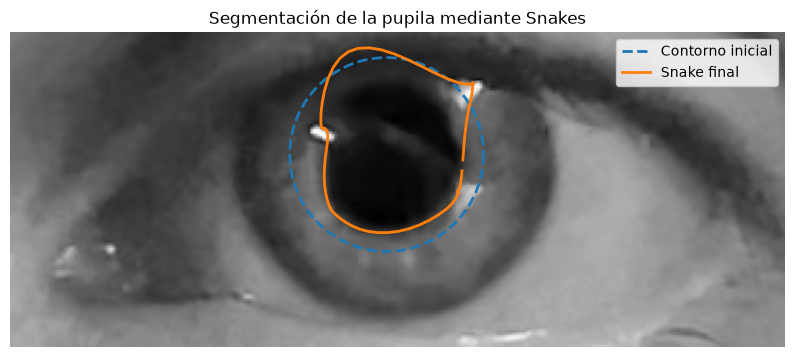

In [56]:
gray_eye = roi_gray.astype(np.float64) / 255.0
smooth_eye = gaussian(gray_eye, sigma=2)

center_x = 155
center_y = 50

# Un poco más grande que la pupila
radius_x = 40
radius_y = 40
theta = np.linspace(0, 2*np.pi, 150)

x = center_x + radius_x * np.cos(theta)
y = center_y + radius_y * np.sin(theta)

init = np.column_stack((y, x))

snake = active_contour(
    smooth_eye,
    init,
    alpha=0.0005,
    beta=0.05,
    gamma=0.1,
    w_line=0.1,
    w_edge=1,
    max_num_iter=1300,
    convergence=0.001
)

plt.figure(figsize=(10, 7))

plt.imshow(gray_eye, cmap="gray")

plt.plot(
    init[:, 1],
    init[:, 0],
    "--",
    linewidth=2,
    label="Contorno inicial"
)

plt.plot(
    snake[:, 1],
    snake[:, 0],
    linewidth=2,
    label="Snake final"
)

plt.title("Segmentación de la pupila mediante Snakes")
plt.legend()
plt.axis("off")
plt.show()

Antes de aplicar Watershed, primero calculamos el gradiente de la imagen y definimos marcadores de regiones. 

Decidimos aumentar el contraste de la imagen porque no se observaba bien el cambio entre el iris y la pupila ya a simple vista. 

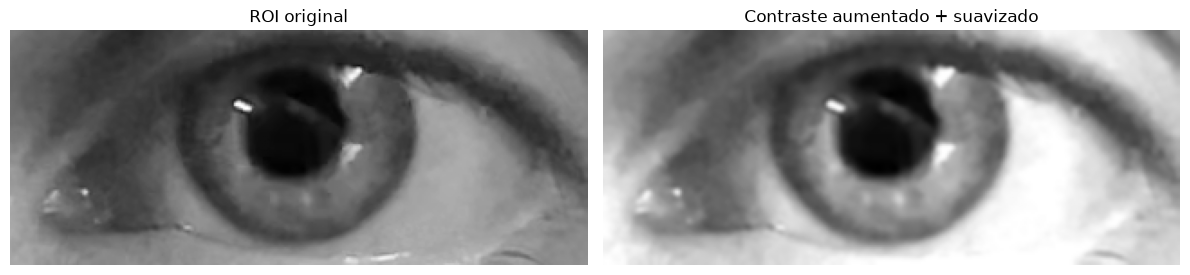

In [ ]:
roi_contraste = np.clip(
    roi_gray.astype(np.float32) * 1.5,
    0,
    255
).astype(np.uint8)

roi_suavizada = cv2.GaussianBlur(
    roi_contraste,
    (5, 5),
    0
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(roi_suavizada, cmap="gray")
plt.title("Contraste aumentado + suavizado")
plt.axis("off")

plt.tight_layout()
plt.show()

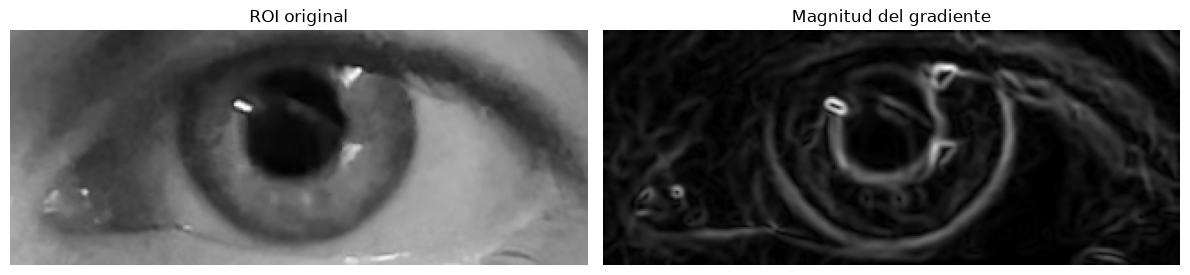

In [70]:
# Gradiente horizontal y vertical
grad_x = cv2.Sobel(
    roi_suavizada,
    cv2.CV_64F,
    1, 0,
    ksize=7
)

grad_y = cv2.Sobel(
    roi_suavizada,
    cv2.CV_64F,
    0, 1,
    ksize=7
)

# Magnitud del gradiente
gradiente = cv2.magnitude(
    grad_x.astype(np.float32),
    grad_y.astype(np.float32)
)

# Normalización para visualizar
gradiente_norm = cv2.normalize(
    gradiente,
    None,
    0, 255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gradiente_norm, cmap="gray")
plt.title("Magnitud del gradiente")
plt.axis("off")

plt.tight_layout()
plt.show()

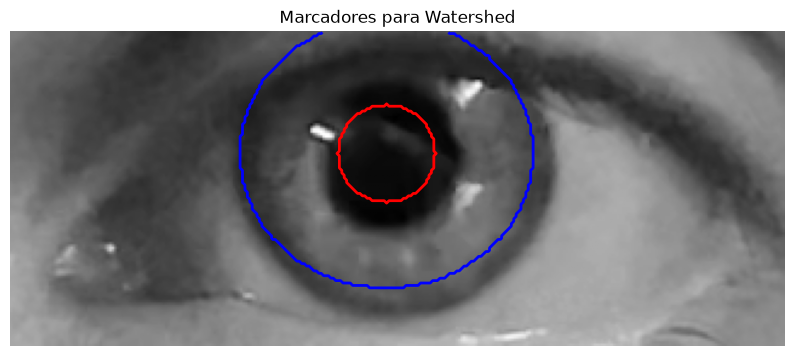

In [ ]:
markers = np.zeros(roi_gray.shape, dtype=np.int32)

# -------------------------
# FOREGROUND SEGURO
# -------------------------
# Región pequeña dentro de la pupila
cv2.circle(
    markers,
    (int(center_x), int(center_y)),
    20,
    1,
    -1
)

# Todo lo que esté fuera de esta elipse
# se considera background seguro.
roi_mask = np.zeros(roi_gray.shape, dtype=np.uint8)

cv2.ellipse(
    roi_mask,
    (int(center_x), int(center_y)),
    (60, 55),
    0,
    0,
    360,
    1,
    -1
)

# Background seguro = fuera de la elipse
markers[roi_mask == 0] = 2

plt.figure(figsize=(10, 7))

plt.imshow(roi_gray, cmap="gray")

plt.contour(
    markers == 1,
    colors="r",
    linewidths=2
)

plt.contour(
    markers == 2,
    colors="b",
    linewidths=2
)

plt.title("Marcadores para Watershed")
plt.axis("off")
plt.show()

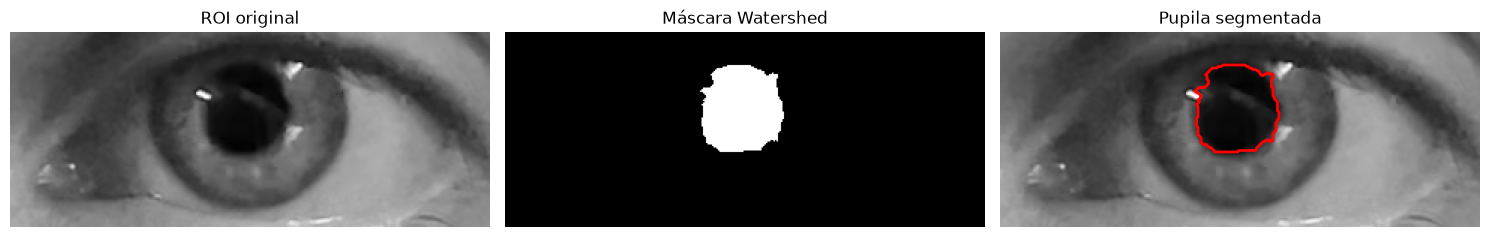

In [79]:
roi_bgr = cv2.cvtColor(
    roi_suavizada,
    cv2.COLOR_GRAY2BGR
)

markers_ws = cv2.watershed(
    roi_bgr,
    markers.copy()
)

mask_watershed = (markers_ws == 1).astype(np.uint8) * 255

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_watershed, cmap="gray")
plt.title("Máscara Watershed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(roi_gray, cmap="gray")
plt.contour(
    mask_watershed > 0,
    colors="r",
    linewidths=2
)
plt.title("Pupila segmentada")
plt.axis("off")

plt.tight_layout()
plt.show()

Con el método de Watershed, se obtiene un contorno bastante cercano al de la pupila pero irregular. 